# Analisis Hasil Inferensi Model U-Net dan ProCANet

Notebook ini berisi analisis kuantitatif dan kualitatif hasil inferensi segmentasi banjir wilayah Sumatera untuk model U-Net dan ProCANet.

## 1. Setup dan Konfigurasi

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Base paths
ROOT = Path("..")
UNET_METRICS_PATH = ROOT / "infer" / "unet" / "metrics.json"
PROCANET_METRICS_PATH = ROOT / "infer" / "procanet" / "metrics.json"

## 2. Analisis Metrik Kuantitatif

### 2.1 Perbandingan Metrik Agregat

In [2]:
# Load JSON metrics
with open(UNET_METRICS_PATH) as f:
    unet_data = json.load(f)
with open(PROCANET_METRICS_PATH) as f:
    procanet_data = json.load(f)

# Extract aggregate metrics
unet_agg = [m for m in unet_data["metrics"] if m["region"] == "aggregate"][0]
procanet_agg = [m for m in procanet_data["metrics"] if m["region"] == "aggregate"][0]

# Construct comparative DataFrame
df_agg = pd.DataFrame([unet_agg, procanet_agg])
df_agg["model"] = ["U-Net", "ProCANet"]
df_agg = df_agg[["model", "loss", "iou", "dice", "accuracy", "tp", "tn", "fp", "fn", "batches"]]
df_agg

,model,loss,iou,dice,accuracy,tp,tn,fp,fn,batches
0,U-Net,0.578075,0.757566,0.862063,0.982597,48031996,819863307,9954748,5416295,281
1,ProCANet,0.628987,0.752900,0.859033,0.982858,46133450,821991992,7826063,7314841,557


### 2.2 Perbandingan Metrik per Wilayah

In [3]:
# Load regional metrics (exclude aggregate)
unet_regions = [m for m in unet_data["metrics"] if m["region"] != "aggregate"]
procanet_regions = [m for m in procanet_data["metrics"] if m["region"] != "aggregate"]

df_unet = pd.DataFrame(unet_regions)
df_procanet = pd.DataFrame(procanet_regions)

# Merge
df_merged = pd.merge(
    df_unet, df_procanet,
    on="region",
    suffixes=("_unet", "_procanet")
)

# Display comparative table
df_merged[["region", "iou_unet", "iou_procanet", "dice_unet", "dice_procanet", "loss_unet", "loss_procanet"]]

,region,iou_unet,iou_procanet,dice_unet,dice_procanet,loss_unet,loss_procanet
0,Aceh_Utara,0.850989,0.838295,0.919497,0.912036,0.351376,0.478579
1,Pidie,0.833099,0.840271,0.908952,0.913204,0.641479,0.629784
2,Pidie_Jaya,0.796069,0.792392,0.886457,0.884172,0.567375,0.589951
3,Aceh_Besar,0.789023,0.765817,0.882072,0.867380,0.411914,0.542921
4,Banda_Aceh,0.585860,0.547235,0.738855,0.707372,0.419684,0.634097
5,Aceh_Tamiang,0.610033,0.618907,0.757790,0.764599,0.575398,0.619713
6,Aceh_Timur,0.692156,0.692677,0.818076,0.818440,0.654071,0.700681
7,Bireuen,0.766998,0.783555,0.868137,0.878644,0.621517,0.616430
8,Langsa,0.392706,0.384330,0.563947,0.555258,0.664865,0.820734
9,Agam,0.550406,0.547770,0.710015,0.707819,0.595712,0.647021


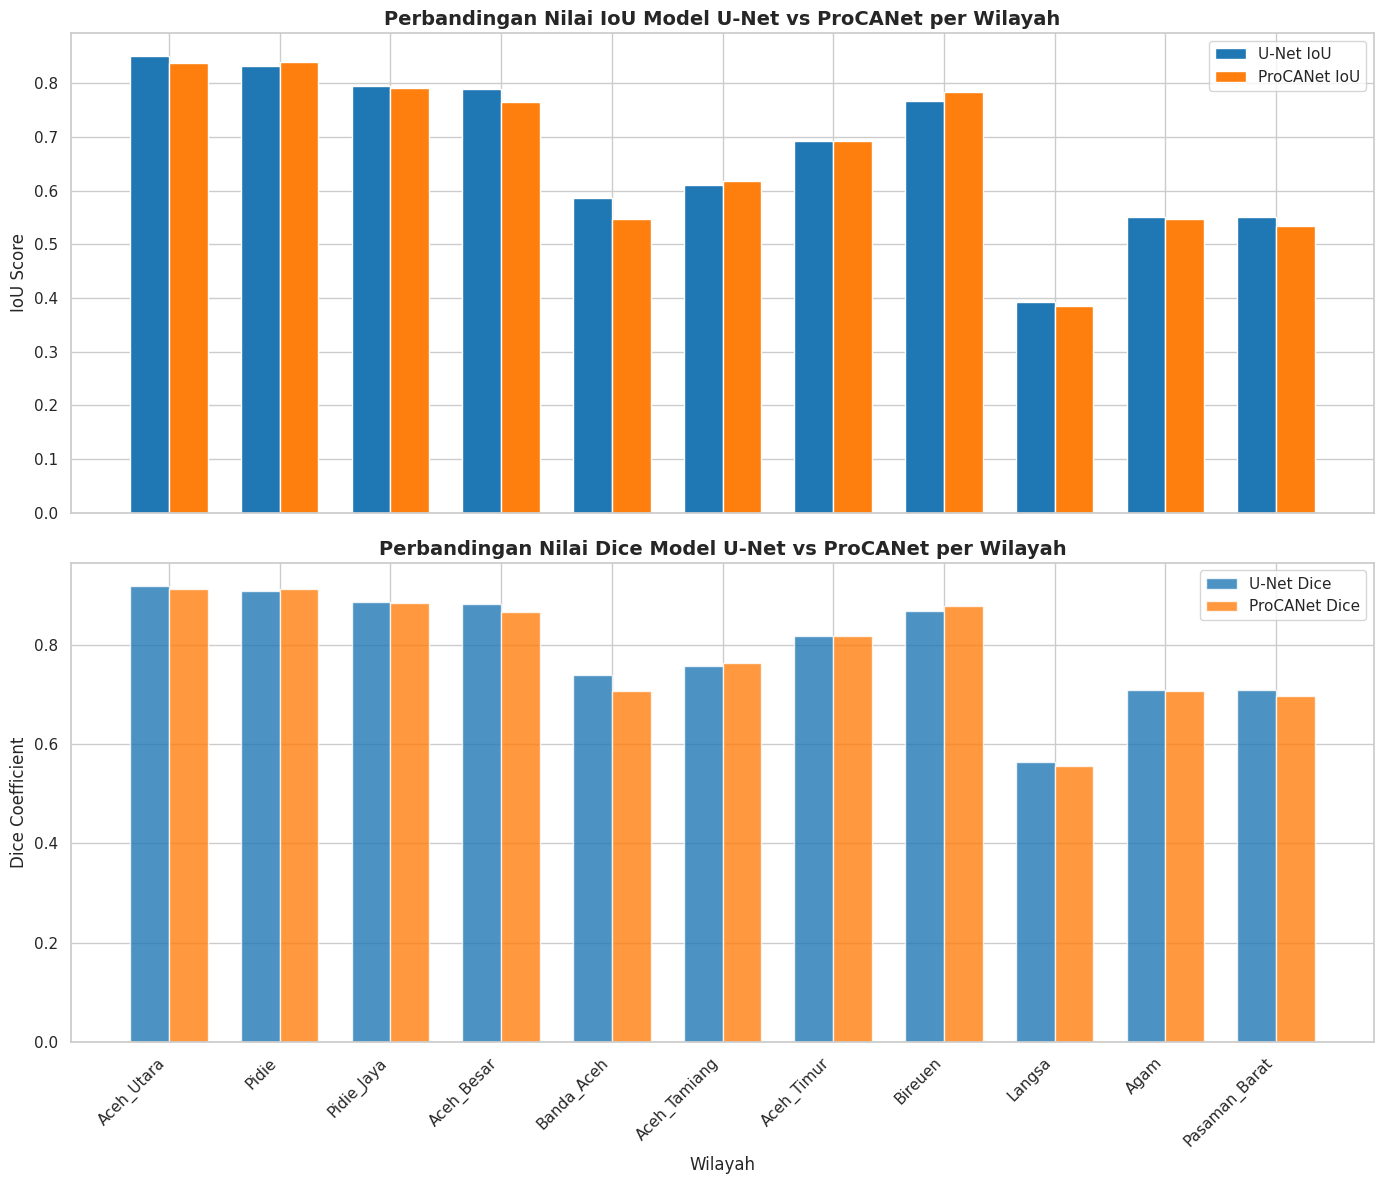

In [4]:
# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
x = np.arange(len(df_merged))
width = 0.35

# IoU comparison
axes[0].bar(x - width/2, df_merged["iou_unet"], width, label="U-Net IoU", color="#1f77b4")
axes[0].bar(x + width/2, df_merged["iou_procanet"], width, label="ProCANet IoU", color="#ff7f0e")
axes[0].set_ylabel("IoU Score")
axes[0].set_title("Perbandingan Nilai IoU Model U-Net vs ProCANet per Wilayah", fontsize=14, fontweight="bold")
axes[0].legend()

# Dice comparison
axes[1].bar(x - width/2, df_merged["dice_unet"], width, label="U-Net Dice", color="#1f77b4", alpha=0.8)
axes[1].bar(x + width/2, df_merged["dice_procanet"], width, label="ProCANet Dice", color="#ff7f0e", alpha=0.8)
axes[1].set_ylabel("Dice Coefficient")
axes[1].set_title("Perbandingan Nilai Dice Model U-Net vs ProCANet per Wilayah", fontsize=14, fontweight="bold")
axes[1].legend()

plt.xticks(x, df_merged["region"], rotation=45, ha="right")
plt.xlabel("Wilayah")
plt.tight_layout()
plt.show()

## 3. Analisis Kinerja Tingkat Ubin (Tile-level Analysis)

Bagian ini memindai ubin di wilayah `Aceh_Utara` untuk mengidentifikasi ubin dengan kinerja terbaik dan terburuk (berdasarkan IoU) untuk analisis visual lebih lanjut.

In [5]:
def analyze_tiles_in_region(region="Aceh_Utara"):
    unet_pred_dir = ROOT / "infer" / "unet" / "predictions" / region
    procanet_pred_dir = ROOT / "infer" / "procanet" / "predictions" / region
    
    tile_stats = []
    
    for unet_path in sorted(unet_pred_dir.glob("*.npz")):
        tile_name = unet_path.name
        procanet_path = procanet_pred_dir / tile_name
        
        if not procanet_path.exists():
            continue
            
        unet_tile = np.load(unet_path)
        procanet_tile = np.load(procanet_path)
        
        y = unet_tile["y"].squeeze()
        eff_mask = unet_tile["effective_valid_mask"].squeeze()
        
        unet_pred = unet_tile["prediction"].squeeze()
        procanet_pred = procanet_tile["prediction"].squeeze()
        
        valid_pixels = eff_mask.sum()
        if valid_pixels == 0:
            continue
            
        def calculate_tile_iou(pred, target, mask):
            tp = ((pred == 1) & (target == 1) & mask).sum()
            fp = ((pred == 1) & (target == 0) & mask).sum()
            fn = ((pred == 0) & (target == 1) & mask).sum()
            den = tp + fp + fn
            return tp / den if den > 0 else 0.0
            
        u_iou = calculate_tile_iou(unet_pred, y, eff_mask)
        p_iou = calculate_tile_iou(procanet_pred, y, eff_mask)
        
        tile_stats.append({
            "tile_name": tile_name,
            "unet_iou": u_iou,
            "procanet_iou": p_iou,
            "y_sum": y[eff_mask].sum(),
            "valid_pixels": valid_pixels
        })
        
    return pd.DataFrame(tile_stats)

df_tiles = analyze_tiles_in_region("Aceh_Utara")

# Filter ubin yang memiliki luasan banjir signifikan (>5000 piksel) dan valid area cukup besar (>100000 piksel)
df_interesting = df_tiles[(df_tiles["y_sum"] > 5000) & (df_tiles["valid_pixels"] > 100000)].copy()

best_unet = df_interesting.sort_values(by="unet_iou", ascending=False).iloc[0]
worst_unet = df_interesting.sort_values(by="unet_iou", ascending=True).iloc[0]

print("=== Ubin U-Net Terbaik ===")
print(best_unet)
print("\n=== Ubin U-Net Terburuk ===")
print(worst_unet)

=== Ubin U-Net Terbaik ===
tile_name       Aceh_Utara_r000512_c007424.npz
unet_iou                              0.979683
procanet_iou                          0.967232
y_sum                                 190207.0
valid_pixels                            203077
Name: 48, dtype: object

=== Ubin U-Net Terburuk ===
tile_name       Aceh_Utara_r003328_c007168.npz
unet_iou                              0.459243
procanet_iou                          0.545351
y_sum                                  11063.0
valid_pixels                            227391
Name: 371, dtype: object


## 4. Visualisasi Perbandingan Model (Input, GT, Prediksi)

Visualisasi menggunakan grid 2x3 untuk menampilkan input Sentinel-1 (SAR VV), Sentinel-2 (Pseudo-RGB), DEMNAS Slope, Ground Truth (UNOSAT), dan prediksi dari masing-masing model.

In [6]:
def plot_tile_comparison(tile_name, region="Aceh_Utara"):
    # Load features from corresponding tile directory based on model setup
    unet_feat_path = ROOT / "dataset" / "tiles" / "7ch" / "by_region" / region / tile_name
    
    # Load feature files
    feat_data = np.load(unet_feat_path)
    x = feat_data["x"]  # shape (7, 512, 512)
    
    vv = x[0]
    hue, sat, val = x[2], x[3], x[4]
    slope = x[5]
    
    # Reconstruct RGB from HSV
    hsv_img = np.stack([hue, sat, val], axis=-1)
    hsv_img = np.clip(hsv_img, 0.0, 1.0)
    rgb = mcolors.hsv_to_rgb(hsv_img)
    
    # Load predictions
    unet_pred_data = np.load(ROOT / "infer" / "unet" / "predictions" / region / tile_name)
    procanet_pred_data = np.load(ROOT / "infer" / "procanet" / "predictions" / region / tile_name)
    
    y_gt = unet_pred_data["y"].squeeze()
    eff_mask = unet_pred_data["effective_valid_mask"].squeeze()
    
    unet_pred = unet_pred_data["prediction"].squeeze()
    procanet_pred = procanet_pred_data["prediction"].squeeze()
    
    def mask_invalid(image, mask):
        masked = np.copy(image).astype(float)
        masked[~mask] = np.nan
        return masked
        
    y_gt_masked = mask_invalid(y_gt, eff_mask)
    unet_pred_masked = mask_invalid(unet_pred, eff_mask)
    procanet_pred_masked = mask_invalid(procanet_pred, eff_mask)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # S1 SAR
    im0 = axes[0, 0].imshow(vv, cmap="gray")
    axes[0, 0].set_title("Sentinel-1 SAR (VV Normalized)")
    fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)
    
    # S2 RGB
    s2_mask = feat_data.get("s2_valid_mask")
    if s2_mask is not None:
        s2_mask_2d = s2_mask.squeeze().astype(bool)
        rgb_masked = np.copy(rgb)
        rgb_masked[~s2_mask_2d] = 0.5
        axes[0, 1].imshow(rgb_masked)
    else:
        axes[0, 1].imshow(rgb)
    axes[0, 1].set_title("Sentinel-2 Pseudo-RGB")
    
    # Slope
    im2 = axes[0, 2].imshow(slope, cmap="terrain")
    axes[0, 2].set_title("DEMNAS Slope (Normalized)")
    fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)
    
    cmap_seg = mcolors.ListedColormap(["#2ca02c", "#1f77b4"])
    cmap_seg.set_bad(color="#d3d3d3")
    
    # Ground Truth
    im3 = axes[1, 0].imshow(y_gt_masked, cmap=cmap_seg, vmin=0, vmax=1)
    axes[1, 0].set_title("Ground Truth (UNOSAT)")
    cbar3 = fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04, ticks=[0.25, 0.75])
    cbar3.ax.set_yticklabels(["Non-Flood", "Flood"])
    
    # U-Net
    im4 = axes[1, 1].imshow(unet_pred_masked, cmap=cmap_seg, vmin=0, vmax=1)
    axes[1, 1].set_title("U-Net Prediction")
    cbar4 = fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04, ticks=[0.25, 0.75])
    cbar4.ax.set_yticklabels(["Non-Flood", "Flood"])
    
    # ProCANet
    im5 = axes[1, 2].imshow(procanet_pred_masked, cmap=cmap_seg, vmin=0, vmax=1)
    axes[1, 2].set_title("ProCANet Prediction")
    cbar5 = fig.colorbar(im5, ax=axes[1, 2], fraction=0.046, pad=0.04, ticks=[0.25, 0.75])
    cbar5.ax.set_yticklabels(["Non-Flood", "Flood"])
    
    for row in axes:
        for ax in row:
            ax.set_xticks([])
            ax.set_yticks([])
            
    fig.suptitle(f"Visualisasi Perbandingan Model\nTile: {tile_name}", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

Plotting best tile...


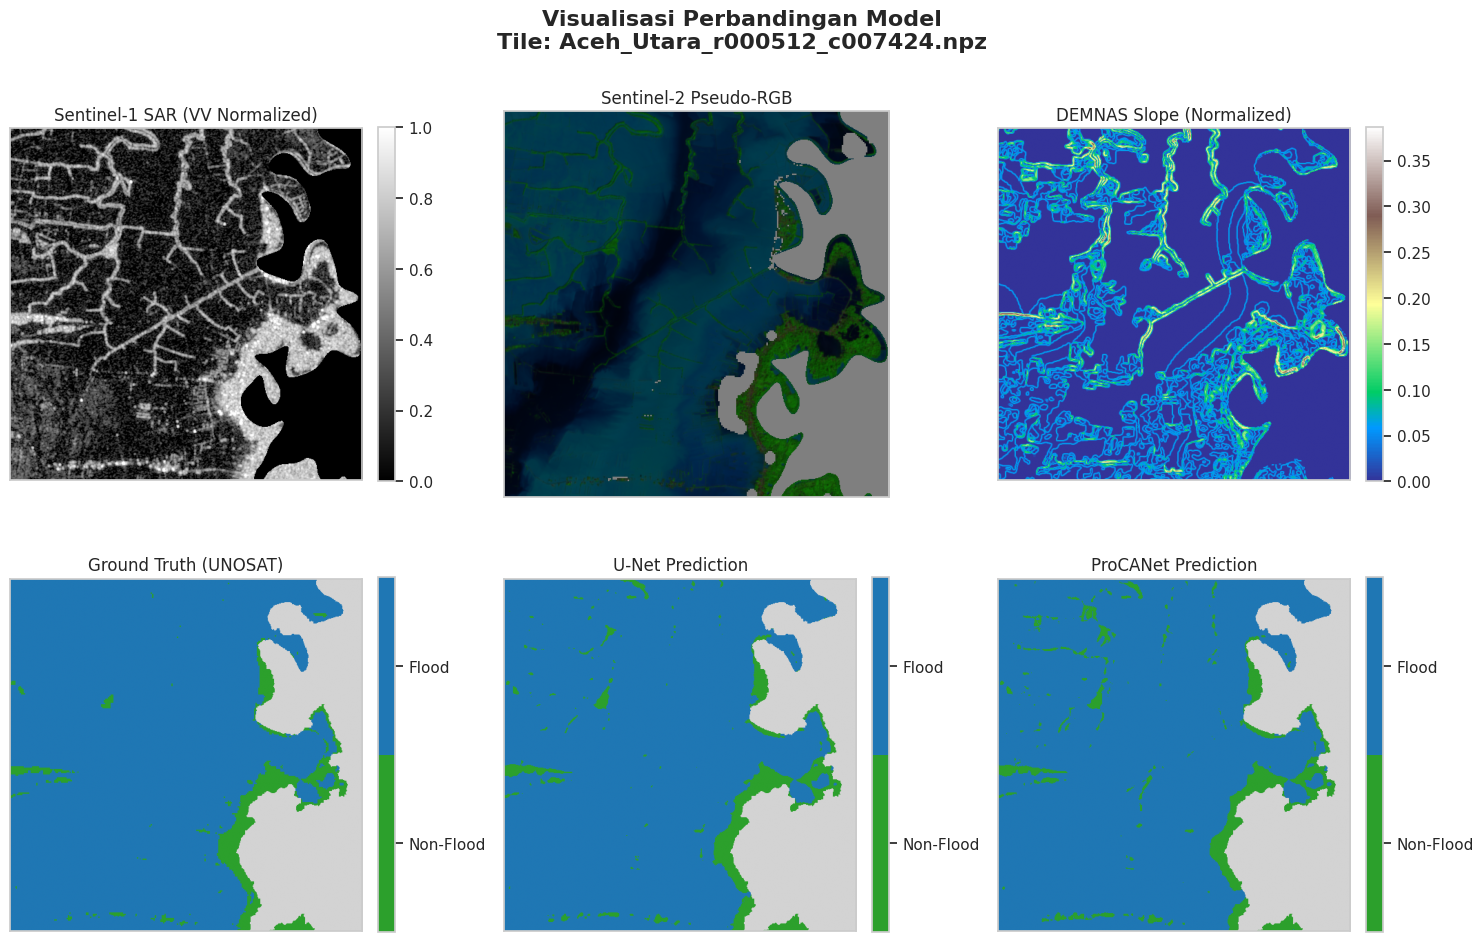

Plotting worst tile...


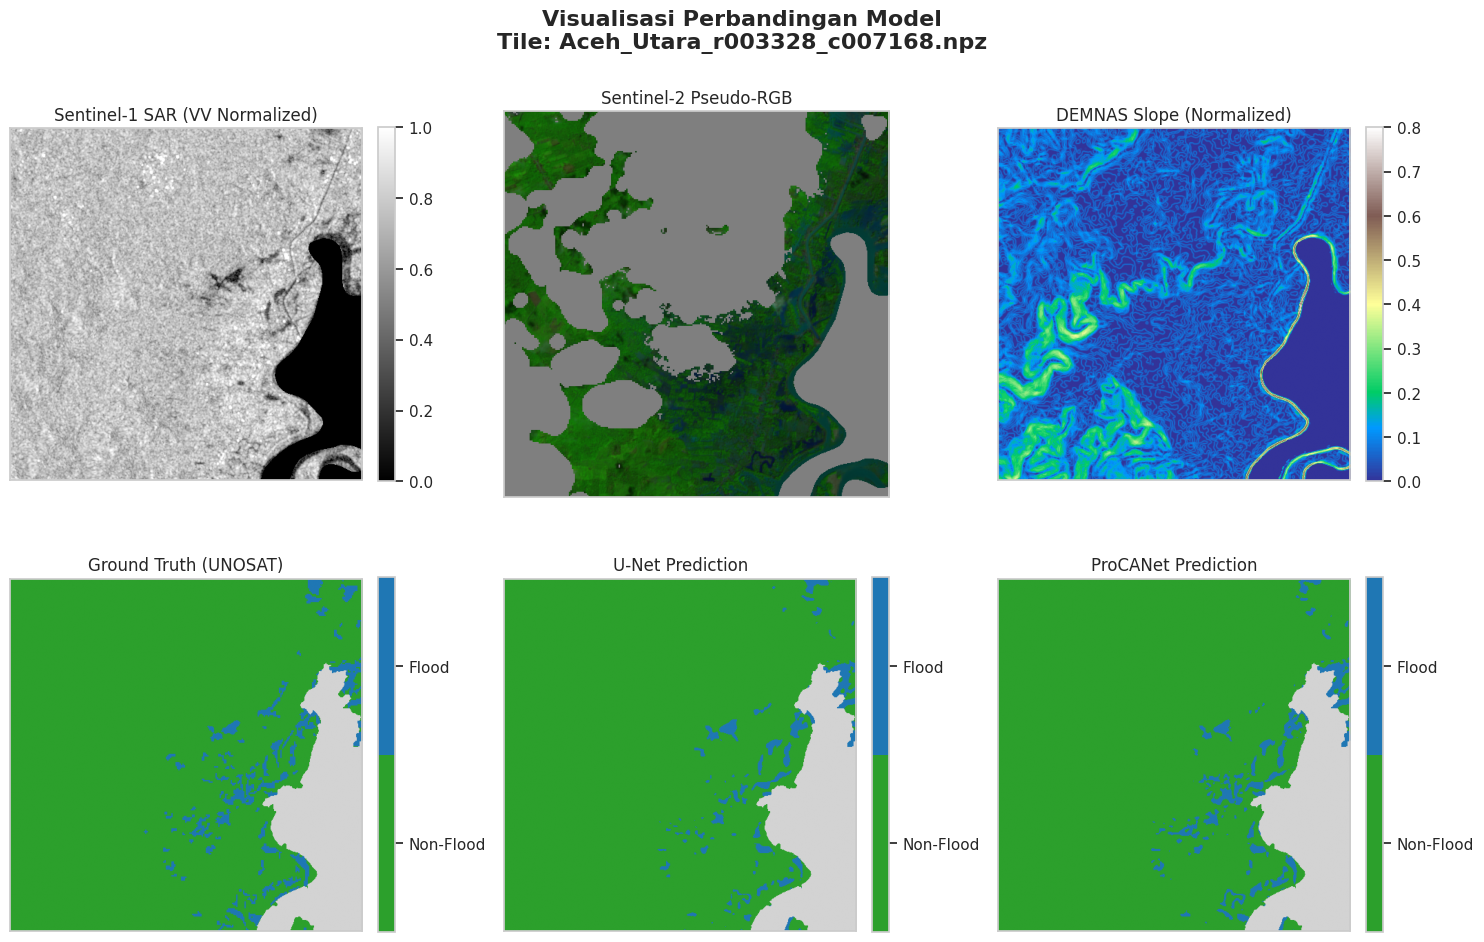

In [7]:
print("Plotting best tile...")
plot_tile_comparison(best_unet["tile_name"])
print("Plotting worst tile...")
plot_tile_comparison(worst_unet["tile_name"])

## 5. Analisis Kesalahan Spasial (Spatial Error Analysis)

Bagian ini memetakan tipe-tipe kesalahan model secara spasial:
- **True Negative (TN)**: Putih (tidak banjir diprediksi tidak banjir)
- **True Positive (TP)**: Hijau (banjir diprediksi banjir)
- **False Positive (FP)**: Merah (tidak banjir tetapi diprediksi banjir oleh model)
- **False Negative (FN)**: Kuning (banjir tetapi tidak terdeteksi oleh model)

In [8]:
def plot_spatial_errors(tile_name, region="Aceh_Utara"):
    unet_pred_data = np.load(ROOT / "infer" / "unet" / "predictions" / region / tile_name)
    procanet_pred_data = np.load(ROOT / "infer" / "procanet" / "predictions" / region / tile_name)
    
    y = unet_pred_data["y"].squeeze()
    eff_mask = unet_pred_data["effective_valid_mask"].squeeze()
    
    unet_pred = unet_pred_data["prediction"].squeeze()
    procanet_pred = procanet_pred_data["prediction"].squeeze()
    
    def get_error_map(pred, target, mask):
        # TN: 0, TP: 1, FP: 2, FN: 3
        err_map = np.zeros_like(pred, dtype=float)
        err_map[(pred == 0) & (target == 0)] = 0  # TN
        err_map[(pred == 1) & (target == 1)] = 1  # TP
        err_map[(pred == 1) & (target == 0)] = 2  # FP
        err_map[(pred == 0) & (target == 1)] = 3  # FN
        err_map[~mask] = np.nan
        return err_map
        
    unet_err = get_error_map(unet_pred, y, eff_mask)
    procanet_err = get_error_map(procanet_pred, y, eff_mask)
    
    # Custom color map: TN (White), TP (Green), FP (Red), FN (Yellow)
    colors = ["#ffffff", "#2ca02c", "#d62728", "#bcbd22"]
    cmap_err = mcolors.ListedColormap(colors)
    cmap_err.set_bad(color="#d3d3d3")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    im_u = axes[0].imshow(unet_err, cmap=cmap_err, vmin=0, vmax=3)
    axes[0].set_title(f"U-Net Spatial Errors\nTile: {tile_name}", fontsize=14, fontweight="bold")
    cbar_u = fig.colorbar(im_u, ax=axes[0], fraction=0.046, pad=0.04, ticks=[0.375, 1.125, 1.875, 2.625])
    cbar_u.ax.set_yticklabels(["TN", "TP", "FP", "FN"])
    
    im_p = axes[1].imshow(procanet_err, cmap=cmap_err, vmin=0, vmax=3)
    axes[1].set_title(f"ProCANet Spatial Errors\nTile: {tile_name}", fontsize=14, fontweight="bold")
    cbar_p = fig.colorbar(im_p, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0.375, 1.125, 1.875, 2.625])
    cbar_p.ax.set_yticklabels(["TN", "TP", "FP", "FN"])
    
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.tight_layout()
    plt.show()

Plotting spatial errors for worst tile...


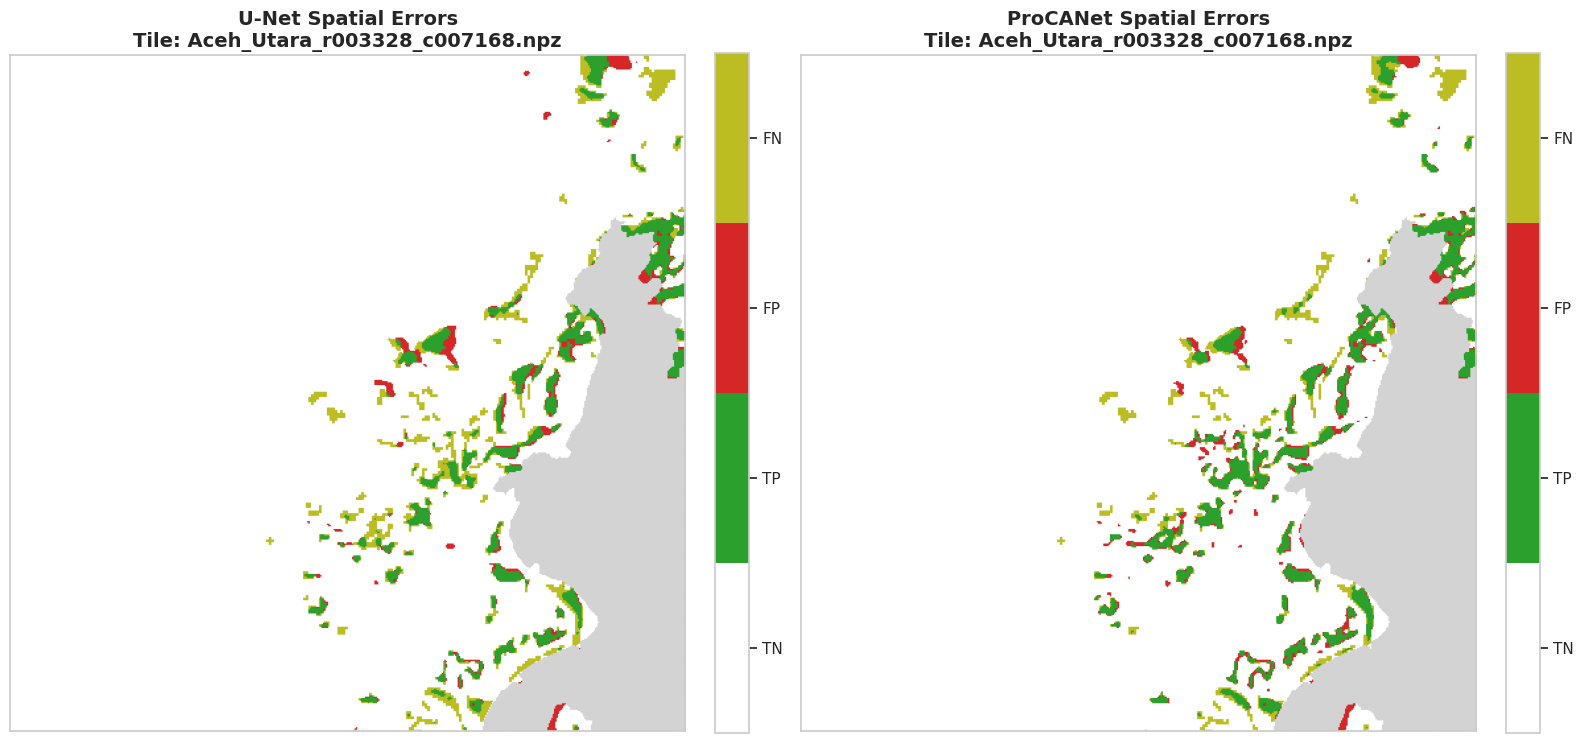

In [9]:
print("Plotting spatial errors for worst tile...")
plot_spatial_errors(worst_unet["tile_name"])

Plotting spatial errors for best tile...


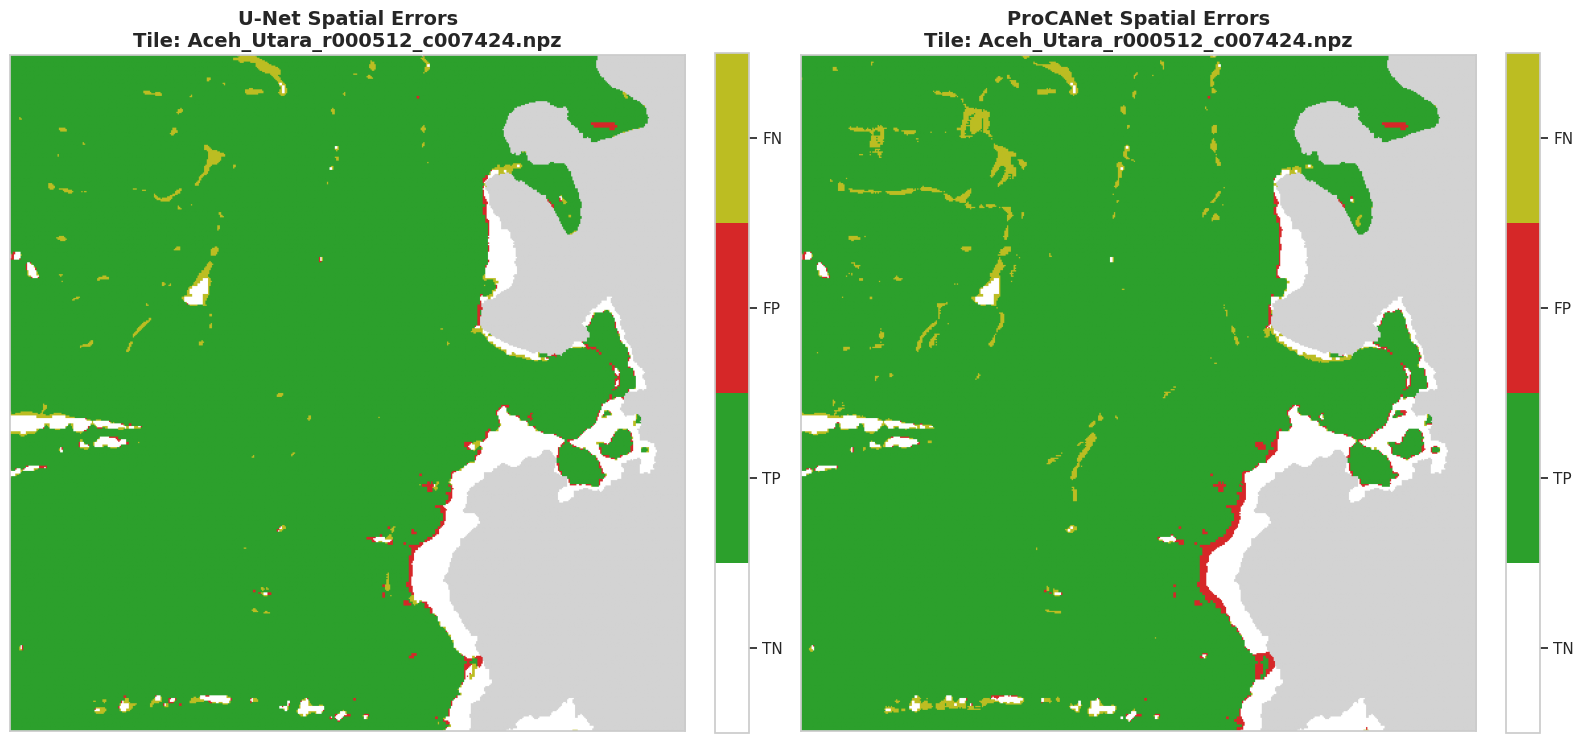

In [10]:
print("Plotting spatial errors for best tile...")
plot_spatial_errors(best_unet["tile_name"])